In [9]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score
from plot_decision_boundaries import plot_decision_boundaries
from plot_gaussian_mixture import plot_gaussian_mixture
from plot_dbscan import plot_dbscan


In [10]:
train = pd.read_csv("samsung_train.txt",sep=r"\s+",header=None)
train_labels = pd.read_csv("samsung_train_labels.txt",sep=r"\s+",header=None)

In [11]:
print("data")
print(train.describe())
print(train.shape)
print("labels")
print(train_labels.describe())
print(train_labels.shape)

data
               0            1            2            3            4    \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000000   
mean      0.274488    -0.017695    -0.109141    -0.605438    -0.510938   
std       0.070261     0.040811     0.056635     0.448734     0.502645   
min      -1.000000    -1.000000    -1.000000    -1.000000    -0.999873   
25%       0.262975    -0.024863    -0.120993    -0.992754    -0.978129   
50%       0.277193    -0.017219    -0.108676    -0.946196    -0.851897   
75%       0.288461    -0.010783    -0.097794    -0.242813    -0.034231   
max       1.000000     1.000000     1.000000     1.000000     0.916238   

               5            6            7            8            9    ...  \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000000  ...   
mean     -0.604754    -0.630512    -0.526907    -0.606150    -0.468604  ...   
std       0.418687     0.424073     0.485942     0.414122     0.544547  ...   
min      -1.

Dane są jakimiś cechami dotyczącymi aktywności. Jedna kolumna jedna osoba 561 cech można znaleźć jakie w Human Activity Recognition - nie wiele mówi dokładnie zapoznawanie się z tymi cechami.
Mamy już zbiór podzielony na wartości testowe i treningowe. Można by je połączyć i ponownie zrobić split, ale skoro są podane w takiej formie to tak bym je pozostawił bo takie jest zapewne założenie i taki gotowy podział lepiej obroni model przed potencjalnymi błędami. Więc mamy już teoretycznie przygotowany X_train X_test y_train i y_test.
Wydaje mi się że nie potrzebujemy na tym etapie znać tych cech czym dokłądnie są bo możemy najpierw skorzystać z klasteringu i zobaczyć jakie grupy nam wyjdą dopiero wtedy próbować je określić?.
Dane są wyskalowane w zakresie od -1,1 więc skalowanie też już jest wykonane, przynajmniej tak wynika ze strony Human Activity Recognition Using Smartphones

In [12]:
X_train = pd.read_csv("samsung_train.txt",sep=r"\s+",header=None)
y_train = pd.read_csv("samsung_train_labels.txt",sep=r"\s+",header=None)
y_train = y_train.iloc[:, 0]
X_test = pd.read_csv("samsung_test.txt",sep=r"\s+",header=None)
y_test = pd.read_csv("samsung_test_labels.txt",sep=r"\s+",header=None)
y_test = y_test.iloc[:, 0]



In [13]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

print("Braki X_train:", X_train.isna().sum().sum())
print("Braki X_test:", X_test.isna().sum().sum())
print("Duplikaty w X_train:", X_train.duplicated().sum())

(7352, 561)
(7352,)
(2947, 561)
(2947,)
Braki X_train: 0
Braki X_test: 0
Duplikaty w X_train: 0


Dane wyglądają na kompletne i przygotowane do analizy, nie widze błędów zerowych wartości duplikatów. Okazuje się że w danych jest rodzaj aktywności których jest sześć więc tyle należy obrać n_clusters dla KMeans

In [14]:
models = {
    'KMeans': KMeans(
        n_clusters= 6,
        random_state = 1,
        n_init= 10
    ),
    'MiniBatchKMeans': MiniBatchKMeans(
        n_clusters= 6,
        random_state = 1,
        n_init= 10
    ),
    'dbscan' : DBSCAN(
        eps=1,
        min_samples = 5
    ),
    'GaussianMixture' : GaussianMixture(
        n_components= 6,
        random_state= 1
    )
}

supervised_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=  1000,
        random_state= 1
    ),
    'DecissionTreeClassifier': DecisionTreeClassifier(
        random_state= 1
    )
}

Spróbuje sprawdzić jak klasteryzacja poradziła sobie z podzieleniem zbiorów na 6 klastrów ponieważ my tak naprawdę znamy podział który chcielibyśmy uzyskać.

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
clustering_results = {}

for name, model in models.items():
    y_pred = model.fit_predict(X_train)

    ari = adjusted_rand_score(y_train, y_pred)
    nmi = normalized_mutual_info_score(y_train, y_pred)

    clustering_results[name] = {
        "model": model,
        "predictions": y_pred,
        "ARI": ari,
        "NMI": nmi
    }

    print(f"{name}")
    print(f"ARI: {ari:.3f}")
    print(f"NMI: {nmi:.3f}")
    print()



KMeans
ARI: 0.455
NMI: 0.583

MiniBatchKMeans
ARI: 0.462
NMI: 0.591

dbscan
ARI: 0.000
NMI: 0.000

GaussianMixture
ARI: 0.286
NMI: 0.464



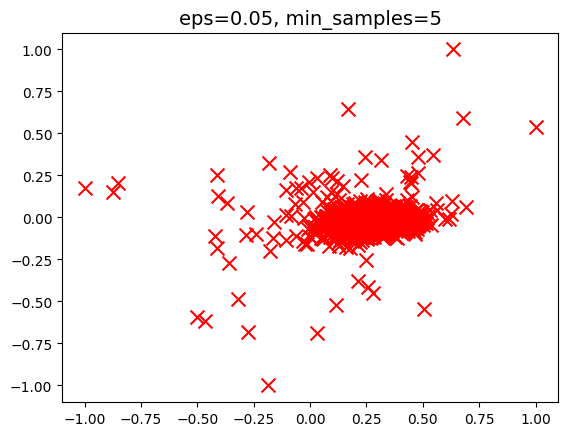

In [21]:
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X_train)
plot_dbscan(dbscan,X_train.to_numpy(),size=100)

Metody wizualizacji w ćwiczeniach niekoniecznie pasują do tych danych?

In [ ]:
preprocessor = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=0.95,
        random_state=1
    ))
])
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clustering", KMeans(
        n_clusters=6,
        random_state=42,
        n_init= 10
        
    )),
    ("classifier", LogisticRegression(
        max_iter=20000
    ))
])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

pipeline_name = "KMeans + Logistic Regression"
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))


KMeans + Logistic Regression
Accuracy: 0.7648456057007126
F1 macro: 0.7559026960998009


In [ ]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000
    ))
])
pipeline_name = "Logistic Regression"
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:",f1_score(y_test, y_pred, average="macro"))

Logistic Regression
Accuracy: 0.9311163895486936
F1 macro: 0.929749794829437


In [ ]:
model_pipeline = Pipeline([
    ("classifier", LogisticRegression(
        max_iter=5000
    ))
])
pipeline_name = "Logistic Regression"
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(pipeline_name)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:",f1_score(y_test, y_pred, average="macro"))

Logistic Regression
Accuracy: 0.9619952494061758
F1 macro: 0.9620578909975772


Wyniki uzyskane przez pipeline w którym robimy klusteryzacje a potem te dane podajemy na metodę supervised w rzeczywistości obcina nam dane i sam model Logistic radzi sobie lepiej.